## 7.16 Trotter화를 이용한 양자 분자동역학

In [1]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Pauli, SparsePauliOp
from qiskit.visualization import plot_bloch_multivector, plot_state_qsphere, plot_state_city, plot_histogram, plot_state_hinton
from qiskit.quantum_info import Statevector, partial_trace
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# 분자 해밀토니안 정의 (예시)
h_pauli_terms = {
    "XX": 0.5,
    "YY": 0.5,
    "ZZ": 1.0
}

In [3]:
# 해밀토니안을 SparsePauliOp로 생성
pauli_labels = [Pauli(label) for label in h_pauli_terms.keys()]
coefficients = np.array(list(h_pauli_terms.values()), dtype=complex)  # 계수를 올바른 형식으로
hamiltonian = SparsePauliOp(pauli_labels, coefficients)

In [4]:
# Trotter화로 시간 진화 연산자 정의
def trotterize(hamiltonian, time, steps):
    dt = time / steps
    trotter_circuit = QuantumCircuit(2)

    for _ in range(steps):
        for pauli_op, coef in zip(hamiltonian.paulis, hamiltonian.coeffs):
            if pauli_op == Pauli("XX"):
                trotter_circuit.rxx(2 * coef.real * dt, 0, 1)
            elif pauli_op == Pauli("YY"):
                trotter_circuit.ryy(2 * coef.real * dt, 0, 1)
            elif pauli_op == Pauli("ZZ"):
                trotter_circuit.rzz(2 * coef.real * dt, 0, 1)

    return trotter_circuit

In [5]:
# 전체 시간과 Trotter 단계 수 정의
total_time = 1.0
time_steps = 10

In [6]:
# Trotter화 양자회로 생성
trotter_circuit = trotterize(hamiltonian, total_time, time_steps)

In [7]:
# 상태벡터 저장
trotter_circuit.save_statevector()

In [8]:
# AerSimulator로 양자회로 시뮬레이션
simulator = AerSimulator(method='statevector')
transpiled_circuit = transpile(trotter_circuit, simulator)

In [9]:
# 시뮬레이션을 실행해 상태벡터 획득
job = simulator.run(transpiled_circuit)
result = job.result()

In [10]:
# 최종 상태벡터 획득
state = result.get_statevector()
print(state)

Statevector([ 5.40302306e-01-8.41470985e-01j,
              0.00000000e+00+0.00000000e+00j,
              0.00000000e+00+0.00000000e+00j,
             -7.30785754e-18+7.15420623e-18j],
            dims=(2, 2))


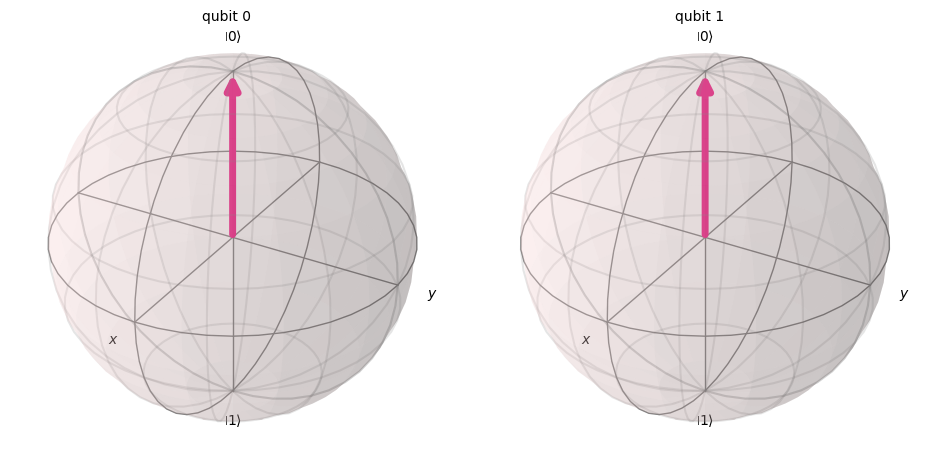

In [11]:
# 여러 시각화로 결과 표현
plot_bloch_multivector(state)
plt.show()

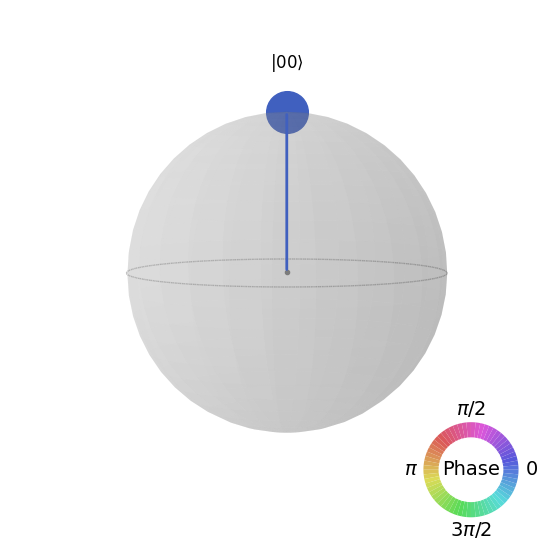

In [12]:
# QSphere 플롯
plot_state_qsphere(state)
plt.show()

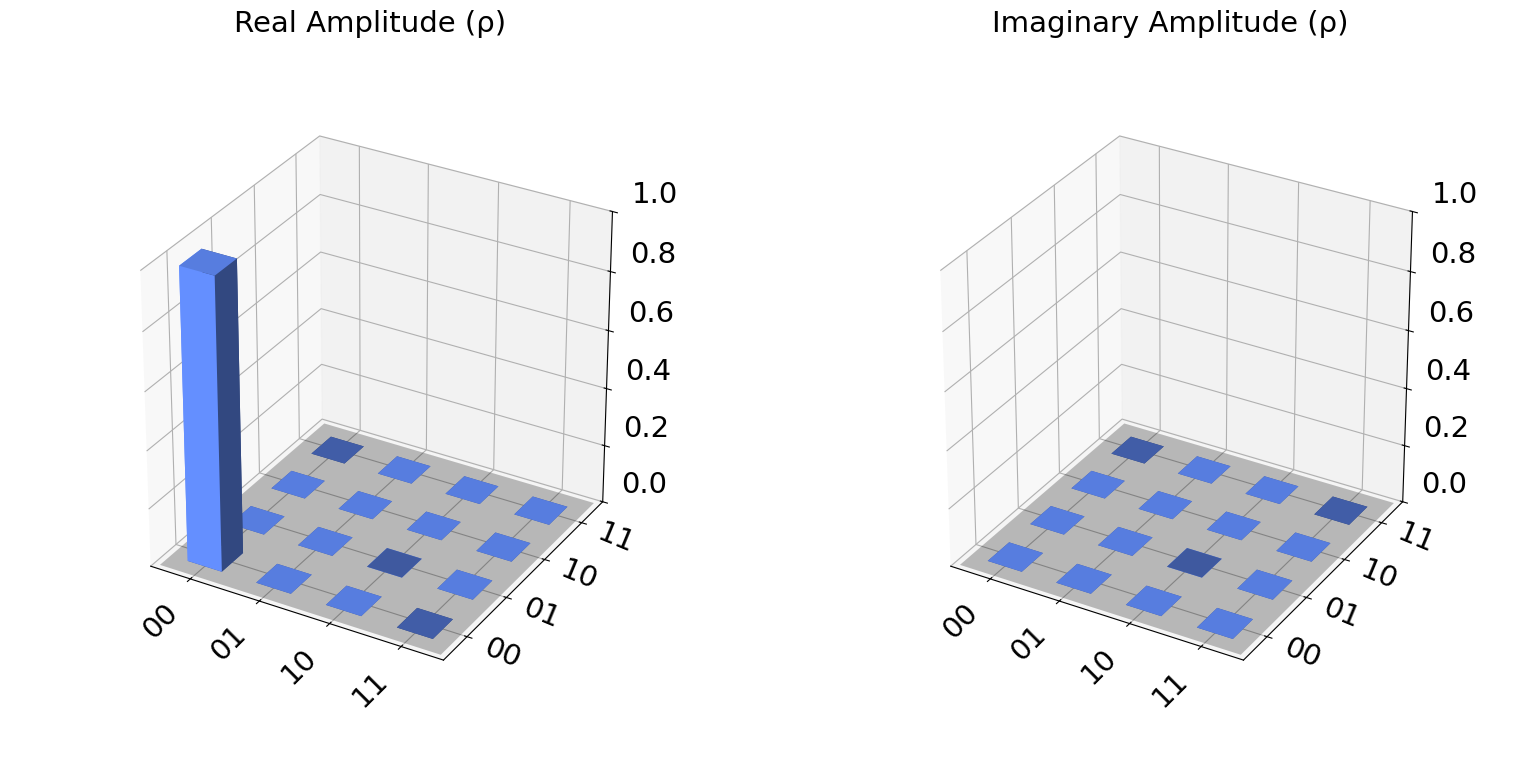

In [13]:
plot_state_city(state)
plt.show()

In [14]:
# # 큐비트 0의 축소 상태를 살펴보는 부분 대각합
# rho = partial_trace(state, [1])
# plot_state_hinton(rho)
# plt.show()

In [15]:
# 결과 히스토그램을 위해 회로에 측정 추가
measured_circuit = trotterize(hamiltonian, total_time, time_steps)
measured_circuit.measure_all()

In [16]:
# 측정이 있는 시뮬레이션 실행
measured_job = simulator.run(measured_circuit)
measured_result = measured_job.result()

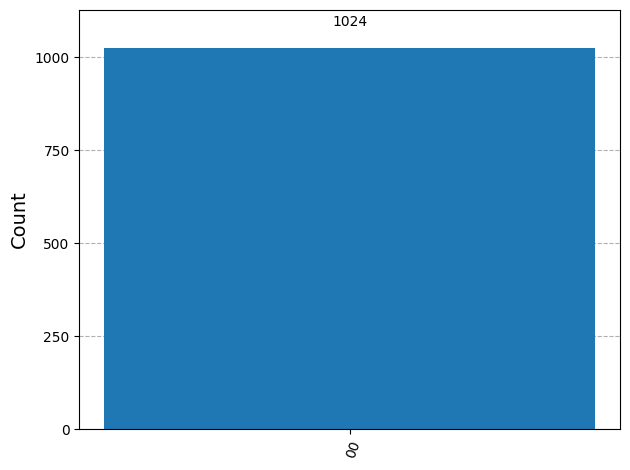

In [17]:
# 측정 카운트 획득 및 시각화
counts = measured_result.get_counts()
plot_histogram(counts)
plt.show()